# UCLA MSBA Lab: Zero-Shot Forecasting, Evaluation, and Judgment

## Learning goals

- Understand what **zero-shot forecasting** means in practice
- evaluate forecasts with the right **time-series metrics**
- compare model outputs against **simple baselines**
- see where language models help with **explanations**, but not **numeric truth**
- make a deployment recommendation grounded in evidence


## Part 0 (0–5 min): Context + Setup

### What this lab demonstrates

- What **zero-shot forecasting** means in practice
- Why **temporal splits** matter
- Why **metrics + baselines** are non-negotiable
- What **LLM-as-Judge** can (and cannot) evaluate

### Open-source components used

- **TSFM path (optional):** Chronos (open-source forecasting model)
- **Local LLM judge path (optional):** Ollama + an open-source instruct model (e.g. `llama3.2:3b`)
- **Evaluation:** pure Python / NumPy / pandas metrics

### Setup (run only if needed)

```bash
# Core notebook deps
pip install -r requirements.txt

# Optional: local open-source LLM judge path
# Install Ollama separately (https://ollama.com), then:
ollama pull llama3.2:3b
```

If Chronos/Ollama are unavailable, the notebook falls back to **offline demo paths** so the class can continue.

In [1]:
import io
import json
import math
import shutil
import subprocess
import textwrap
import urllib.request
from dataclasses import dataclass

import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(suppress=True, precision=4)

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception as e:
    HAS_MPL = False
    print(f"matplotlib not available ({type(e).__name__}): plots will be skipped")

In [2]:
# Classroom-friendly defaults
CONFIG = {
    'dataset_name': 'daily_min_temperature',
    'horizon': 14,
    'context_len': 56,
    'seasonal_period': 7,   # weekly seasonality baseline for daily data
    'train_ratio': 0.75,
    'use_remote_open_dataset': True,   # falls back automatically if offline
    'prefer_chronos': False,            # falls back automatically if unavailable
    'use_ollama_judge': False,          # falls back automatically if unavailable
    'ollama_model': 'llama3.2:3b',
}
CONFIG

{'dataset_name': 'daily_min_temperature',
 'horizon': 14,
 'context_len': 56,
 'seasonal_period': 7,
 'train_ratio': 0.75,
 'use_remote_open_dataset': True,
 'prefer_chronos': False,
 'use_ollama_judge': False,
 'ollama_model': 'llama3.2:3b'}

## Part 1 (5–20 min): Zero-Shot Forecasting (Foundation Model in Action)

### Objective

Experience transfer learning in practice.

Students will:
- load a time series
- perform a proper temporal split
- run **zero-shot forecasting** with a TSFM (Chronos if available)
- visualize forecast vs actuals

In [3]:
OPEN_DATA_URLS = {
    # Public real-world daily temperature dataset commonly used in forecasting tutorials
    'daily_min_temperature': 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
}


def load_open_daily_temperature(timeout_sec=5):
    url = OPEN_DATA_URLS['daily_min_temperature']
    with urllib.request.urlopen(url, timeout=timeout_sec) as resp:
        raw = resp.read()
    df = pd.read_csv(io.BytesIO(raw))
    # Expected columns: Date, Temp
    date_col = [c for c in df.columns if c.lower().startswith('date')][0]
    value_col = [c for c in df.columns if c.lower() in {'temp', 'value'} or c != date_col][0]
    out = pd.DataFrame({
        'timestamp': pd.to_datetime(df[date_col]),
        'value': pd.to_numeric(df[value_col], errors='coerce'),
    }).dropna().reset_index(drop=True)
    out['source'] = 'open_remote_daily_min_temperature'
    return out


def load_offline_fallback_series(n=365*3, seed=42):
    # Offline backup so the seminar can proceed even without internet/model downloads.
    # This is synthetic but shaped like a real weather/energy-style seasonal series.
    r = np.random.default_rng(seed)
    t = np.arange(n)
    y = (
        15
        + 8 * np.sin(2 * np.pi * t / 365)
        + 2 * np.sin(2 * np.pi * t / 7)
        + 0.003 * t
        + r.normal(0, 1.5, n)
    )
    y[700:760] += 2.0
    ts = pd.date_range('2020-01-01', periods=n, freq='D')
    return pd.DataFrame({'timestamp': ts, 'value': y, 'source': 'offline_fallback_synthetic'})


def load_series(config):
    if config['use_remote_open_dataset']:
        try:
            df = load_open_daily_temperature(timeout_sec=5)
            print('Loaded open-source real dataset:', df['source'].iloc[0], 'rows=', len(df))
            return df
        except Exception as e:
            print(f"Remote open dataset unavailable ({type(e).__name__}: {e}). Falling back to offline series.")
    df = load_offline_fallback_series()
    print('Loaded fallback dataset:', df['source'].iloc[0], 'rows=', len(df))
    return df

series_df = load_series(CONFIG)
series_df.head()

Loaded open-source real dataset: open_remote_daily_min_temperature rows= 3650


,timestamp,value,source
0,1981-01-01,20.7,open_remote_daily_min_temperature
1,1981-01-02,17.9,open_remote_daily_min_temperature
2,1981-01-03,18.8,open_remote_daily_min_temperature
3,1981-01-04,14.6,open_remote_daily_min_temperature
4,1981-01-05,15.8,open_remote_daily_min_temperature


In [4]:
@dataclass
class TemporalSplit:
    train: pd.Series
    test: pd.Series
    train_idx: np.ndarray
    test_idx: np.ndarray


def temporal_train_test_split(values: np.ndarray, train_ratio=0.75):
    n = len(values)
    n_train = int(n * train_ratio)
    train = values[:n_train]
    test = values[n_train:]
    return TemporalSplit(
        train=pd.Series(train),
        test=pd.Series(test),
        train_idx=np.arange(0, n_train),
        test_idx=np.arange(n_train, n),
    )

values = series_df['value'].astype(float).to_numpy()
split = temporal_train_test_split(values, CONFIG['train_ratio'])
print('train len:', len(split.train), 'test len:', len(split.test))

train len: 2737 test len: 913


In [5]:
def make_test_origin_context(series_values, train_end, context_len, horizon, stride=None):
    if stride is None:
        stride = horizon
    starts, contexts, futures = [], [], []
    start0 = max(0, train_end - context_len)
    last_start = len(series_values) - context_len - horizon
    for s in range(start0, last_start + 1, stride):
        ctx_end = s + context_len
        fut_end = ctx_end + horizon
        if ctx_end < train_end:
            continue
        starts.append(s)
        contexts.append(series_values[s:ctx_end])
        futures.append(series_values[ctx_end:fut_end])
    return np.array(starts), np.array(contexts, dtype=float), np.array(futures, dtype=float)

starts, X_ctx, Y_true = make_test_origin_context(
    values,
    train_end=len(split.train),
    context_len=CONFIG['context_len'],
    horizon=CONFIG['horizon'],
    stride=CONFIG['horizon'],
)
print('rolling test windows:', X_ctx.shape, Y_true.shape)

rolling test windows: (65, 56) (65, 14)


In [6]:
def try_chronos_zero_shot(contexts: np.ndarray, horizon: int):
    """Attempt open-source Chronos zero-shot forecasting. Returns (preds, meta)."""
    try:
        import torch  # noqa: F401
        from chronos import ChronosPipeline
    except Exception as e:
        return None, {'path': 'chronos', 'used': False, 'reason': f'import failed: {type(e).__name__}: {e}'}

    try:
        # CPU-friendly small model; students can change this if they have stronger hardware.
        model_id = 'amazon/chronos-t5-small'
        pipeline = ChronosPipeline.from_pretrained(model_id, device_map='cpu')
        preds = []
        for ctx in contexts:
            forecast = pipeline.predict(context=torch.tensor(ctx, dtype=torch.float32), prediction_length=horizon)
            # Chronos often returns samples; use median across samples if needed
            arr = forecast.detach().cpu().numpy()
            if arr.ndim == 2:
                pred = np.median(arr, axis=0)
            elif arr.ndim == 3:
                pred = np.median(arr[0], axis=0)
            else:
                pred = arr.reshape(-1)[:horizon]
            preds.append(pred)
        return np.array(preds, dtype=float), {'path': 'chronos', 'used': True, 'model_id': model_id}
    except Exception as e:
        return None, {'path': 'chronos', 'used': False, 'reason': f'runtime failed: {type(e).__name__}: {e}'}


def offline_proxy_zero_shot(contexts: np.ndarray, horizon: int, seasonal_period: int = 7):
    """Offline fallback that behaves like a frozen forecasting model (not a real TSFM)."""
    preds = []
    for ctx in contexts:
        x = np.asarray(ctx, dtype=float)
        last = x[-1]

        # Seasonal component from same day previous week (if available)
        seasonal = []
        for h in range(horizon):
            idx = len(x) - seasonal_period + (h % seasonal_period)
            seasonal.append(x[idx] if 0 <= idx < len(x) else last)
        seasonal = np.array(seasonal, dtype=float)

        # Local trend estimate (robust-ish)
        k = min(14, len(x))
        recent = x[-k:]
        t = np.arange(k, dtype=float)
        slope = ((t - t.mean()) @ (recent - recent.mean())) / (((t - t.mean()) @ (t - t.mean())) + 1e-6)
        trend = recent[-1] + slope * np.arange(1, horizon + 1)

        # Blend trend + seasonal (acts as a "frozen model" surrogate for offline teaching)
        pred = 0.65 * seasonal + 0.35 * trend
        preds.append(pred)
    return np.array(preds, dtype=float), {'path': 'offline_proxy', 'used': True, 'note': 'Fallback when Chronos is unavailable'}

if CONFIG['prefer_chronos']:
    Y_pred_zero, zero_meta = try_chronos_zero_shot(X_ctx, CONFIG['horizon'])
else:
    Y_pred_zero, zero_meta = (None, {'path': 'chronos', 'used': False, 'reason': 'disabled in CONFIG'})

if Y_pred_zero is None:
    Y_pred_zero, zero_meta = offline_proxy_zero_shot(X_ctx, CONFIG['horizon'], CONFIG['seasonal_period'])

print('Zero-shot path meta:', zero_meta)
print('Prediction shape:', Y_pred_zero.shape)

Zero-shot path meta: {'path': 'offline_proxy', 'used': True, 'note': 'Fallback when Chronos is unavailable'}
Prediction shape: (65, 14)


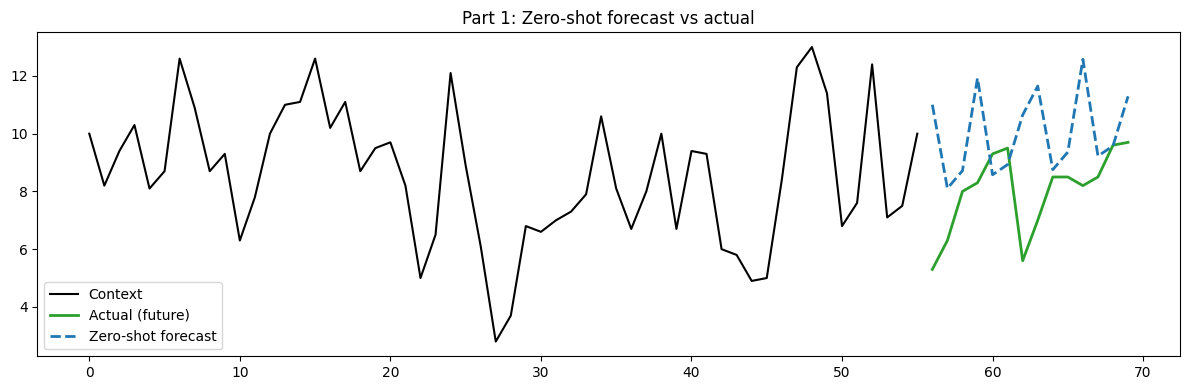

In [7]:
# Visualize one forecast window
example_i = min(1, len(X_ctx) - 1)
ctx = X_ctx[example_i]
truth = Y_true[example_i]
pred = Y_pred_zero[example_i]

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(12, 4))
    x_ctx = np.arange(len(ctx))
    x_fut = np.arange(len(ctx), len(ctx) + len(truth))
    ax.plot(x_ctx, ctx, label='Context', color='black')
    ax.plot(x_fut, truth, label='Actual (future)', color='tab:green', linewidth=2)
    ax.plot(x_fut, pred, label='Zero-shot forecast', color='tab:blue', linestyle='--', linewidth=2)
    ax.set_title('Part 1: Zero-shot forecast vs actual')
    ax.legend(loc='best')
    plt.tight_layout()
else:
    print('Plot skipped (matplotlib unavailable).')
    print('Context tail:', np.round(ctx[-10:], 2))
    print('Actual future:', np.round(truth, 2))
    print('Pred future  :', np.round(pred, 2))

## Part 2 (20–35 min): Build an Evaluation Mindset

### Objective

Move from “looks good” to measurable reliability.

Students will:
- compute `MAE`, `RMSE`, `sMAPE`
- create baselines (`last value`, `seasonal naive`)
- compare zero-shot model vs baselines
- discuss whether the model actually adds value

In [8]:
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def smape(y_true, y_pred, eps=1e-6):
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100 * np.mean(2 * np.abs(y_true - y_pred) / denom))


def flatten2d(a):
    return np.asarray(a).reshape(-1)


def metric_row(model_name, y_true_2d, y_pred_2d):
    yt = flatten2d(y_true_2d)
    yp = flatten2d(y_pred_2d)
    return {
        'model': model_name,
        'MAE': mae(yt, yp),
        'RMSE': rmse(yt, yp),
        'sMAPE': smape(yt, yp),
    }


def baseline_last_value(contexts, horizon):
    return np.repeat(contexts[:, [-1]], horizon, axis=1)


def baseline_seasonal_naive(contexts, horizon, m=7):
    preds = []
    for ctx in contexts:
        out = []
        for h in range(horizon):
            idx = len(ctx) - m + (h % m)
            out.append(ctx[idx] if 0 <= idx < len(ctx) else ctx[-1])
        preds.append(out)
    return np.array(preds, dtype=float)

Y_pred_last = baseline_last_value(X_ctx, CONFIG['horizon'])
Y_pred_seasonal = baseline_seasonal_naive(X_ctx, CONFIG['horizon'], CONFIG['seasonal_period'])

score_df = pd.DataFrame([
    metric_row('ZeroShot_TSFM_or_Fallback', Y_true, Y_pred_zero),
    metric_row('Baseline_LastValue', Y_true, Y_pred_last),
    metric_row(f"Baseline_SeasonalNaive(m={CONFIG['seasonal_period']})", Y_true, Y_pred_seasonal),
]).sort_values('RMSE').reset_index(drop=True)
score_df

,model,MAE,RMSE,sMAPE
0,ZeroShot_TSFM_or_Fallback,2.762310,3.536697,26.990327
1,Baseline_LastValue,2.790659,3.567529,27.703693
2,Baseline_SeasonalNaive(m=7),2.906044,3.667947,28.758003


In [9]:
# Per-window metric view (useful for robustness / drift discussion)
def per_window_metric_df(y_true_2d, y_pred_2d, name):
    rows = []
    for i in range(len(y_true_2d)):
        rows.append({
            'window': i,
            'model': name,
            'MAE': mae(y_true_2d[i], y_pred_2d[i]),
            'RMSE': rmse(y_true_2d[i], y_pred_2d[i]),
            'sMAPE': smape(y_true_2d[i], y_pred_2d[i]),
        })
    return pd.DataFrame(rows)

pw = pd.concat([
    per_window_metric_df(Y_true, Y_pred_zero, 'ZeroShot_TSFM_or_Fallback'),
    per_window_metric_df(Y_true, Y_pred_seasonal, 'SeasonalNaive'),
], ignore_index=True)

pw.groupby('model')[['MAE','RMSE','sMAPE']].mean().sort_values('RMSE')

,MAE,RMSE,sMAPE
model,,,
ZeroShot_TSFM_or_Fallback,2.762310,3.380794,26.990327
SeasonalNaive,2.906044,3.548352,28.758003


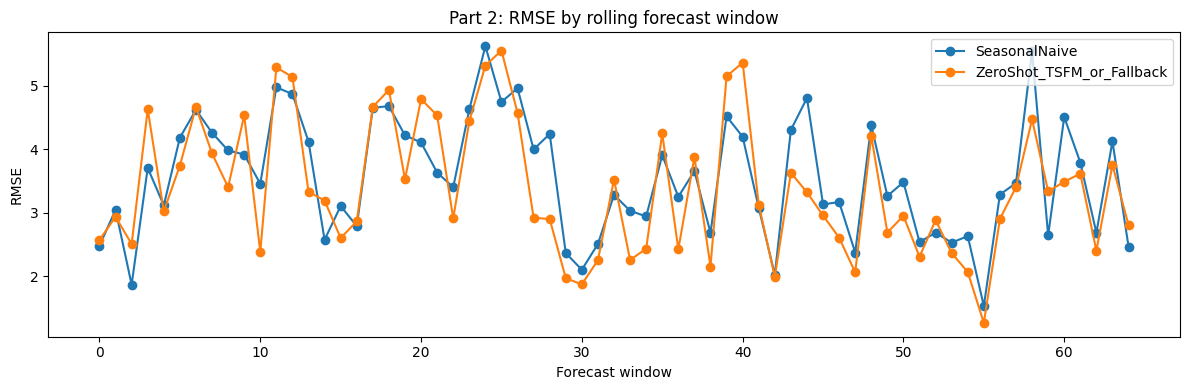

In [10]:
if HAS_MPL:
    fig, ax = plt.subplots(figsize=(12, 4))
    for name, grp in pw.groupby('model'):
        ax.plot(grp['window'], grp['RMSE'], marker='o', label=name)
    ax.set_title('Part 2: RMSE by rolling forecast window')
    ax.set_xlabel('Forecast window')
    ax.set_ylabel('RMSE')
    ax.legend(loc='best')
    plt.tight_layout()
else:
    print('Plot skipped (matplotlib unavailable).')

### Discussion prompts (Part 2)

- Did the zero-shot model beat the naive baselines?
- If yes, by how much? Is it practically meaningful?
- If no, what would you try before deployment?
- Which metric would you prioritize for a business stakeholder?

## Part 3 (35–45 min): LLM-as-Judge (Where It Works and Fails)

### Objective

Understand what LLMs can evaluate — and what they cannot.

Students will:
- write (or inspect) a forecast explanation
- use an LLM to score **clarity/reasoning quality**
- compare explanation score vs numerical forecast metrics

Key point: **LLMs do not replace MAE/RMSE/sMAPE**.

In [11]:
# Create a simple forecast explanation artifact for the example window
example = {
    'context_last_7': np.round(ctx[-7:], 2).tolist(),
    'actual_future': np.round(truth, 2).tolist(),
    'pred_future': np.round(pred, 2).tolist(),
    'zero_shot_path': zero_meta,
}

explanation_good = (
    'The forecast preserves the recent level and weekly seasonality pattern. '
    'It assumes no sudden regime change in the next two weeks, so uncertainty is higher if a heatwave or anomaly occurs. '
    'Operationally, use the forecast as a baseline plan and monitor daily deviations.'
)

explanation_bad = (
    'The forecast is perfect and guaranteed to be accurate because the model is advanced. '
    'No monitoring is needed.'
)

print(json.dumps(example, indent=2)[:1200])
print('\nGood explanation candidate:\n', explanation_good)
print('\nBad explanation candidate:\n', explanation_bad)


{
  "context_last_7": [
    11.4,
    6.8,
    7.6,
    12.4,
    7.1,
    7.5,
    10.0
  ],
  "actual_future": [
    5.3,
    6.3,
    8.0,
    8.3,
    9.3,
    9.5,
    5.6,
    7.0,
    8.5,
    8.5,
    8.2,
    8.5,
    9.6,
    9.7
  ],
  "pred_future": [
    11.0,
    8.1,
    8.72,
    11.93,
    8.58,
    8.93,
    10.65,
    11.65,
    8.75,
    9.36,
    12.58,
    9.22,
    9.58,
    11.29
  ],
  "zero_shot_path": {
    "path": "offline_proxy",
    "used": true,
    "note": "Fallback when Chronos is unavailable"
  }
}

Good explanation candidate:
 The forecast preserves the recent level and weekly seasonality pattern. It assumes no sudden regime change in the next two weeks, so uncertainty is higher if a heatwave or anomaly occurs. Operationally, use the forecast as a baseline plan and monitor daily deviations.

Bad explanation candidate:
 The forecast is perfect and guaranteed to be accurate because the model is advanced. No monitoring is needed.


In [12]:
JUDGE_RUBRIC = {
    'clarity': 'Is the explanation concise and understandable?',
    'reasoning_quality': 'Does it connect the forecast to visible patterns (trend/seasonality)?',
    'uncertainty_calibration': 'Does it acknowledge uncertainty and possible failure modes?',
    'actionability': 'Does it provide useful next-step guidance for a stakeholder?'
}

JUDGE_PROMPT_TEMPLATE = """
You are evaluating the quality of a forecast explanation (NOT the numeric forecast accuracy).
Score each criterion from 1 to 5 and give one short rationale.

Context (recent values): {context_last_7}
Predicted future values: {pred_future}
Candidate explanation: {candidate_explanation}

Criteria:
- clarity
- reasoning_quality
- uncertainty_calibration
- actionability

Return strict JSON with keys: scores, rationale.
""".strip()


def heuristic_text_judge(candidate: str):
    """Offline fallback for classroom continuity when no local LLM is available."""
    text = candidate.lower()
    overconfident = any(w in text for w in ['guaranteed', 'perfect', 'always'])
    denies_monitoring = 'no monitoring' in text or 'monitoring is not needed' in text

    clarity = 4 if len(candidate) < 320 else 2
    reasoning = 4 if any(w in text for w in ['trend', 'season', 'seasonality', 'pattern', 'level']) else 2
    uncertainty = 5 if any(w in text for w in ['uncertainty', 'risk', 'may', 'might']) else 2
    actionability = 4 if any(w in text for w in ['monitor', 'plan', 'baseline', 'action']) else 2

    if overconfident:
        uncertainty = min(uncertainty, 1)
    if denies_monitoring:
        actionability = min(actionability, 1)

    scores = {
        'clarity': clarity,
        'reasoning_quality': reasoning,
        'uncertainty_calibration': uncertainty,
        'actionability': actionability,
    }
    avg = round(sum(scores.values()) / len(scores), 2)
    return {'path': 'heuristic_fallback', 'scores': scores, 'avg_score': avg, 'rationale': 'Heuristic fallback used because no local OSS LLM judge was available.'}


def try_ollama_judge(candidate: str, example_payload: dict, model: str):
    if not shutil.which('ollama'):
        return None, {'path': 'ollama', 'used': False, 'reason': 'ollama CLI not found'}

    prompt = JUDGE_PROMPT_TEMPLATE.format(
        context_last_7=example_payload['context_last_7'],
        pred_future=example_payload['pred_future'],
        candidate_explanation=candidate,
    )

    try:
        proc = subprocess.run(
            ['ollama', 'run', model],
            input=prompt,
            text=True,
            capture_output=True,
            timeout=45,
            check=False,
        )
        if proc.returncode != 0:
            return None, {'path': 'ollama', 'used': False, 'reason': f'ollama failed: {proc.stderr.strip()[:200]}'}
        raw = proc.stdout.strip()
        # Try JSON parse, otherwise return raw text.
        try:
            parsed = json.loads(raw)
        except Exception:
            parsed = {'raw_response': raw}
        return parsed, {'path': 'ollama', 'used': True, 'model': model}
    except Exception as e:
        return None, {'path': 'ollama', 'used': False, 'reason': f'{type(e).__name__}: {e}'}

In [13]:
# Compare LLM-as-judge scores on a better vs worse explanation candidate
judge_outputs = []

for label, candidate in [('good', explanation_good), ('bad', explanation_bad)]:
    result = None
    meta = {'used': False}
    if CONFIG['use_ollama_judge']:
        result, meta = try_ollama_judge(candidate, example, CONFIG['ollama_model'])
    if result is None:
        result = heuristic_text_judge(candidate)
        meta = {'path': 'heuristic_fallback', 'used': True, 'reason': meta.get('reason', 'fallback')}
    judge_outputs.append({'candidate': label, 'judge_meta': meta, 'result': result})

for row in judge_outputs:
    print(f"\nCandidate: {row['candidate']}")
    print('Judge meta:', row['judge_meta'])
    print(json.dumps(row['result'], indent=2)[:1200])



Candidate: good
Judge meta: {'path': 'heuristic_fallback', 'used': True, 'reason': 'fallback'}
{
  "path": "heuristic_fallback",
  "scores": {
    "clarity": 4,
    "reasoning_quality": 4,
    "uncertainty_calibration": 5,
    "actionability": 4
  },
  "avg_score": 4.25,
  "rationale": "Heuristic fallback used because no local OSS LLM judge was available."
}

Candidate: bad
Judge meta: {'path': 'heuristic_fallback', 'used': True, 'reason': 'fallback'}
{
  "path": "heuristic_fallback",
  "scores": {
    "clarity": 4,
    "reasoning_quality": 2,
    "uncertainty_calibration": 1,
    "actionability": 1
  },
  "avg_score": 2.0,
  "rationale": "Heuristic fallback used because no local OSS LLM judge was available."
}


### Critical question (Part 3)

Can the LLM judge detect poor **MAE/RMSE**?